In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 5000

data = pd.DataFrame({
    "hour_of_day": np.random.randint(0,24,N),
    "day_of_week": np.random.randint(0,7,N),
    "num_pois_100m": np.random.randint(0,15,N),
    "num_transit_stops_200m": np.random.randint(0,6,N),
    "area_type": np.random.choice(["residential","commercial","mixed"],N)
})

In [2]:
data["area_type"] = data["area_type"].map({
    "residential":0,
    "mixed":1,
    "commercial":2
})

In [3]:
crowd = (
    0.3 * (data["num_pois_100m"]/15) +
    0.3 * (data["num_transit_stops_200m"]/5) +
    0.2 * (data["area_type"]/2)
)

night_penalty = np.where(data["hour_of_day"] > 22, -0.3, 0)

data["crowd_score"] = np.clip(crowd + night_penalty + np.random.normal(0,0.05,N),0,1)

In [4]:
data["crowd_score"].describe()

count    5000.000000
mean        0.382424
std         0.170339
min         0.000000
25%         0.264571
50%         0.384167
75%         0.502015
max         0.892854
Name: crowd_score, dtype: float64

In [6]:
data.count()

hour_of_day               5000
day_of_week               5000
num_pois_100m             5000
num_transit_stops_200m    5000
area_type                 5000
crowd_score               5000
dtype: int64

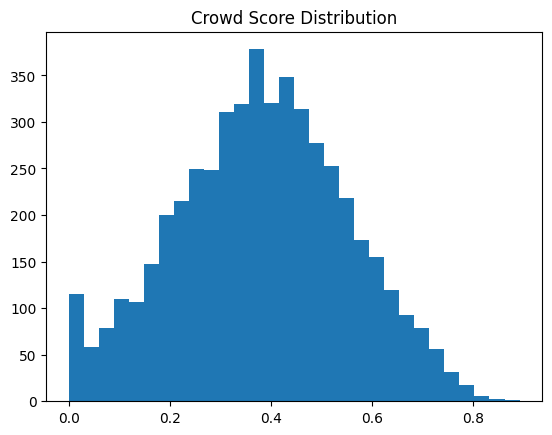

In [8]:
import matplotlib.pyplot as plt

plt.hist(data["crowd_score"], bins=30)
plt.title("Crowd Score Distribution")
plt.show()

In [9]:
X = data.drop("crowd_score", axis=1)
y = data["crowd_score"]

In [11]:
X.shape, y.shape

((5000, 5), (5000,))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

crowd_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3
)

crowd_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [14]:
from sklearn.metrics import mean_squared_error

pred = crowd_model.predict(X_test)

mse = mean_squared_error(y_test, pred)
print("MSE:", mse)

MSE: 0.002427087655593594


In [15]:
pred[:10]


array([0.21600875, 0.52184924, 0.34251179, 0.47428112, 0.23748481,
       0.38101293, 0.40280265, 0.21958307, 0.09009192, 0.31822841])

<Axes: >

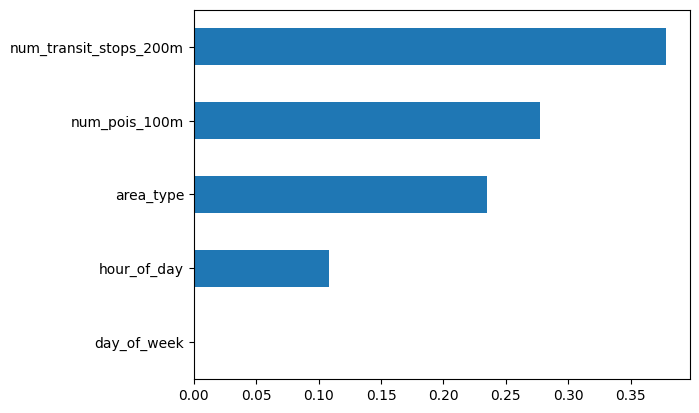

In [16]:
import pandas as pd

importance = pd.Series(
    crowd_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot.barh()

In [17]:
import joblib

joblib.dump(crowd_model, "../app/models/crowd_model.pkl")

['../app/models/crowd_model.pkl']

In [18]:
model = joblib.load("../app/models/crowd_model.pkl")

model.predict(X_test.iloc[:1])

array([0.21600875])

SHOP_MODEL


In [19]:
import numpy as np
import pandas as pd

N = 5000

shop_data = pd.DataFrame({
    "hour_of_day": np.random.randint(0,24,N),
    "num_shops_100m": np.random.randint(0,20,N),
    "area_type": np.random.choice(["residential","mixed","commercial"],N)
})

In [20]:
shop_data["area_type"] = shop_data["area_type"].map({
    "residential":0,
    "mixed":1,
    "commercial":2
})

In [21]:
prob = (
    0.4*(shop_data["num_shops_100m"]/20) +
    0.3*(shop_data["area_type"]/2) +
    0.3*(np.where(
        (shop_data["hour_of_day"]>=9) &
        (shop_data["hour_of_day"]<=21),
        1,0
    ))
)

shop_data["shop_open"] = (
    prob + np.random.normal(0,0.1,N) > 0.5
).astype(int)

In [22]:
from sklearn.linear_model import LogisticRegression

X = shop_data.drop("shop_open",axis=1)
y = shop_data["shop_open"]

shop_model = LogisticRegression()

shop_model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
joblib.dump(shop_model,"../app/models/shop_model.pkl")

['../app/models/shop_model.pkl']